# Mini CNN con TensorFlow (MNIST Local)

## Instrucciones

1. Descarga el archivo `mnist.npz` desde:
https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz

2. Guarda el archivo en la misma carpeta que este notebook.

3. Ejecuta las celdas en orden.


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

## Cargar dataset local

In [4]:
data = np.load('mnist.npz')

train_images = data['x_train']
train_labels = data['y_train']

test_images = data['x_test']
test_labels = data['y_test']

print('Training images:', train_images.shape)
print('Test images:', test_images.shape)

Training images: (60000, 28, 28)
Test images: (10000, 28, 28)


## Visualizar una imagen

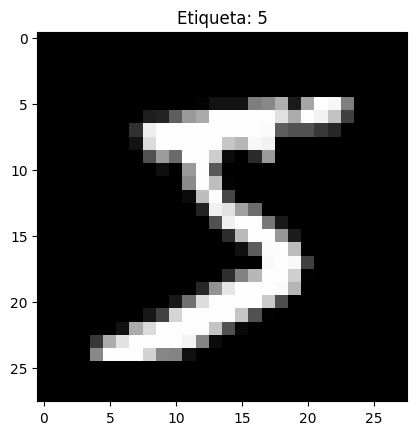

In [5]:
plt.imshow(train_images[0], cmap='gray')
plt.title(f'Etiqueta: {train_labels[0]}')
plt.show()

## Normalizar datos

In [6]:
train_images = train_images / 255.0
test_images = test_images / 255.0

train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

## Crear la CNN

In [7]:
model = models.Sequential()

model.add(layers.Conv2D(8, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.summary()

/Users/alonso284/GitHub/ML/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        43,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,706 (170.73 KB)

 Trainable params: 43,706 (170.73 KB)

 Non-trainable params: 0 (0.00 B)

## Compilar modelo

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Entrenar modelo

In [9]:
history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    validation_data=(test_images, test_labels)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9137 - loss: 0.2900 - val_accuracy: 0.9622 - val_loss: 0.1276
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9700 - loss: 0.1020 - val_accuracy: 0.9736 - val_loss: 0.0839
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9792 - loss: 0.0695 - val_accuracy: 0.9794 - val_loss: 0.0641
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9843 - loss: 0.0525 - val_accuracy: 0.9806 - val_loss: 0.0641
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9863 - loss: 0.0436 - val_accuracy: 0.9792 - val_loss: 0.0649


## Evaluar modelo

In [10]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - accuracy: 0.9792 - loss: 0.0649
Accuracy: 0.979200005531311


## Graficar accuracy

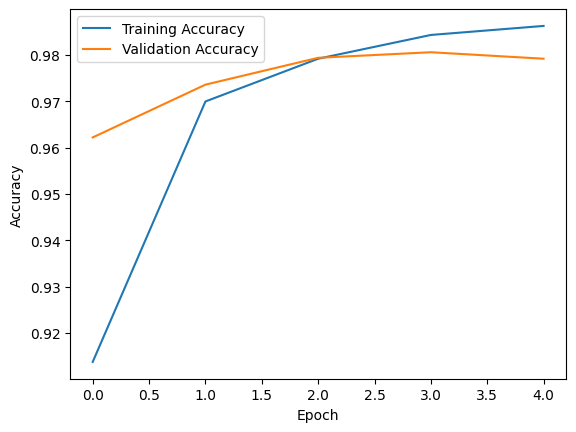

In [11]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Actividad — Construye tu propia CNN

In [12]:
# ==========================================
# ACTIVIDAD:
# CONSTRUYE TU PROPIA CNN
# ==========================================

# INSTRUCCIONES:
#
# Modifica esta red neuronal y analiza qué ocurre.
#
# Debes:
#
# 1. Cambiar el número de filtros
# 2. Agregar otra capa convolucional
# 3. Cambiar el número de neuronas densas
# 4. Probar diferentes cantidades de épocas
#
# Después responde:
#
# - ¿Mejoró el accuracy?
# - ¿El entrenamiento tardó más?
# - ¿Apareció overfitting?
# - ¿Qué configuración funcionó mejor?
#
# ==========================================

from tensorflow.keras import layers, models

student_model = models.Sequential()

# Primera capa convolucional
student_model.add(
    layers.Conv2D(
        17,                 # <- Cambia este número
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

# Pooling
student_model.add(
    layers.MaxPooling2D((2,2))
)

# ==========================================
# ACTIVIDAD:
# Agrega aquí otra capa convolucional
# ==========================================

student_model.add(
    layers.Conv2D(
        8,                 # <- Cambia este número
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

# ==========================================
# Flatten
# ==========================================

student_model.add(layers.Flatten())

# ==========================================
# ACTIVIDAD:
# Cambia el número de neuronas
# ==========================================

student_model.add(
    layers.Dense(
        72,                # <- Cambia este número
        activation='relu'
    )
)

# Capa de salida
student_model.add(
    layers.Dense(10, activation='softmax')
)

# Mostrar estructura
student_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 17)     │           170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 17)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 8)      │         1,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 968)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 72)             │        69,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,900 (280.86 KB)

 Trainable params: 71,900 (280.86 KB)

 Non-trainable params: 0 (0.00 B)

## Compilar y entrenar

In [13]:
# ==========================================
# COMPILAR MODELO
# ==========================================

student_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# ENTRENAR MODELO
# ==========================================

history_student = student_model.fit(
    train_images,
    train_labels,
    
    epochs=5,   # <- Cambia este número
    
    validation_data=(test_images, test_labels)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9441 - loss: 0.1831 - val_accuracy: 0.9758 - val_loss: 0.0750
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9811 - loss: 0.0614 - val_accuracy: 0.9855 - val_loss: 0.0446
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9866 - loss: 0.0432 - val_accuracy: 0.9835 - val_loss: 0.0480
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9897 - loss: 0.0325 - val_accuracy: 0.9872 - val_loss: 0.0391
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9921 - loss: 0.0249 - val_accuracy: 0.9866 - val_loss: 0.0433


## Evaluación

In [14]:
# ==========================================
# EVALUAR MODELO
# ==========================================

test_loss, test_acc = student_model.evaluate(
    test_images,
    test_labels
)

print("Accuracy final:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - accuracy: 0.9866 - loss: 0.0433
Accuracy final: 0.9865999817848206


## Graficar entrenamiento

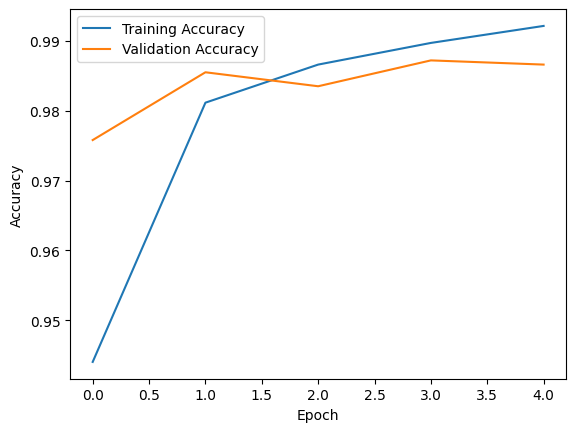

In [15]:
# ==========================================
# GRAFICAR ACCURACY
# ==========================================

import matplotlib.pyplot as plt

plt.plot(
    history_student.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_student.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

## Preguntas para análisis
1. ¿Qué ocurrió al aumentar los filtros?

> Aumentó el accuracy

2. ¿Qué pasó cuando agregaste otra capa convolucional?

> Aumentó el accuracy (y tardó más en entrenar)

3. ¿Cómo cambió el tiempo de entrenamiento?

> Tardó casi 6 segundos más

4. ¿Qué configuración obtuvo el mejor accuracy?

> La segunda, con doble conv layer

5. ¿Hubo overfitting? ¿Cómo lo identificaste?

> No, por que validation, aunque es menor que accuracy, sigue estando alto

6. ¿Qué diferencia observaste entre training accuracy y validation accuracy?

> Ambos son altos, pero accuracy es mayor (aunque no por mucho)

## Reto Extra
Intenta superar 98% de accuracy sin usar más de 10 épocas.